In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer


In [46]:
data = pd.read_csv('/content/Breast_cancer_dataset.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [47]:
df = data.iloc[:,:32]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [48]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [49]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [50]:
df = df.drop(['id'], axis=1)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df['diagnosis'] = df['diagnosis'].str.strip().map({'M': 1, 'B': 0})
corr = df.corr(numeric_only=True)['diagnosis'].sort_values(ascending=False)
corr

,diagnosis
diagnosis,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


<Axes: >

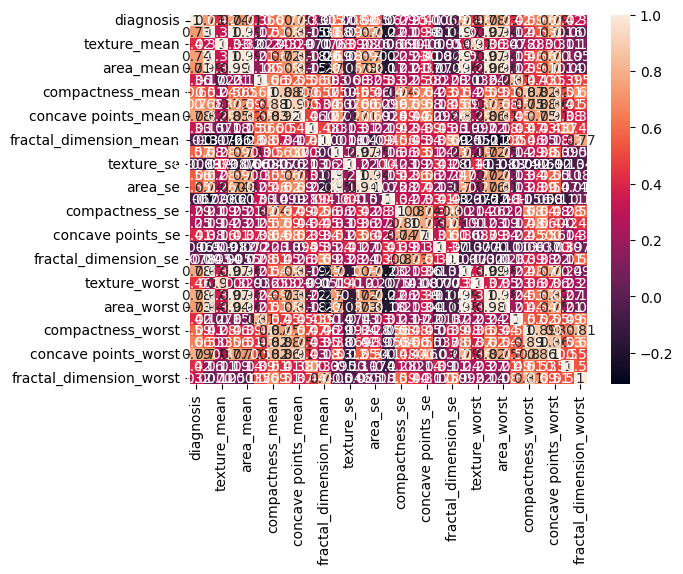

In [53]:
sns.heatmap(df.corr(), annot=True)

In [54]:
x = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']

In [55]:
numerical_col = x.select_dtypes(include=np.number).columns

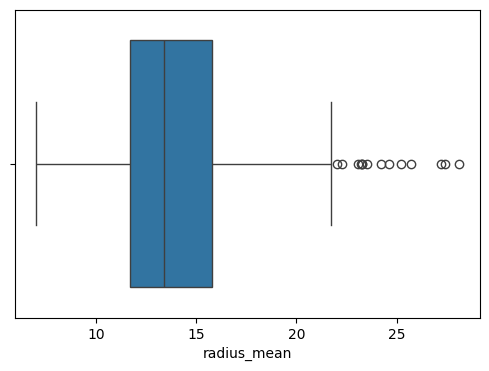

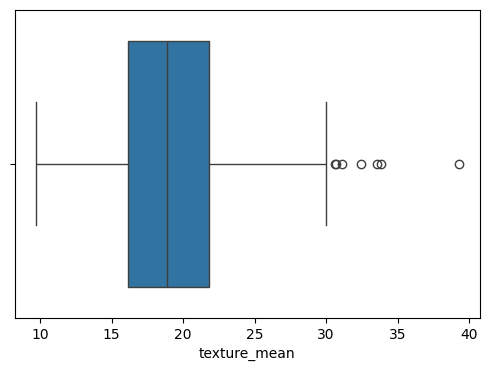

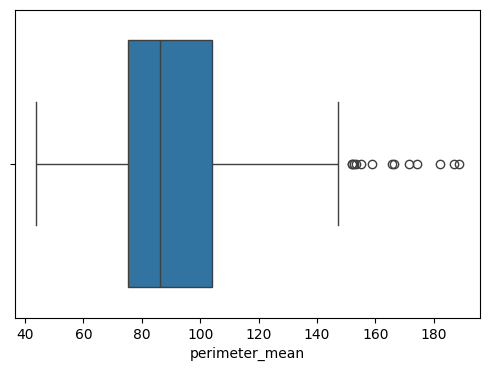

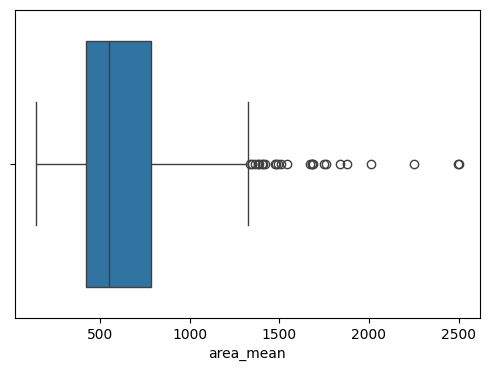

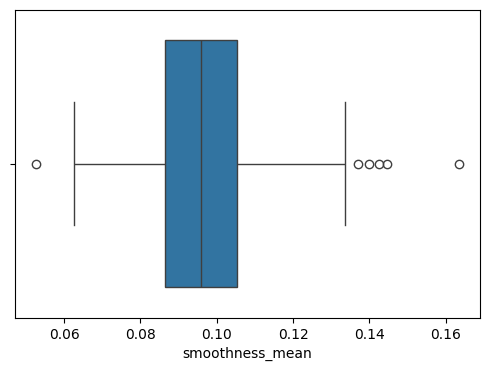

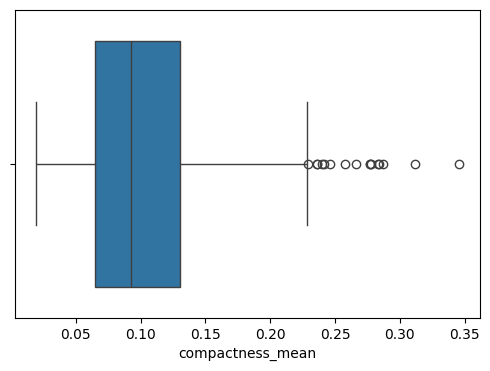

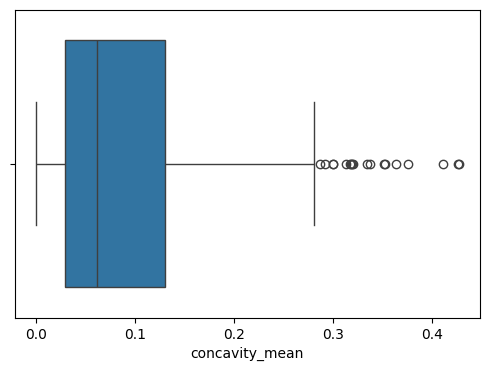

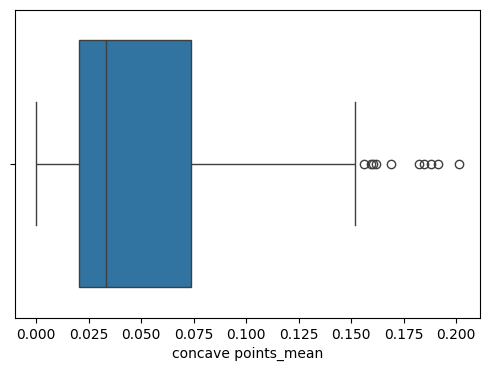

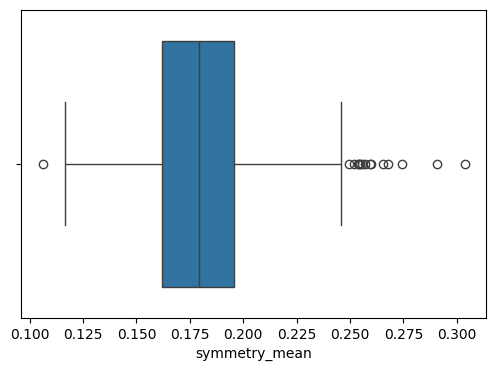

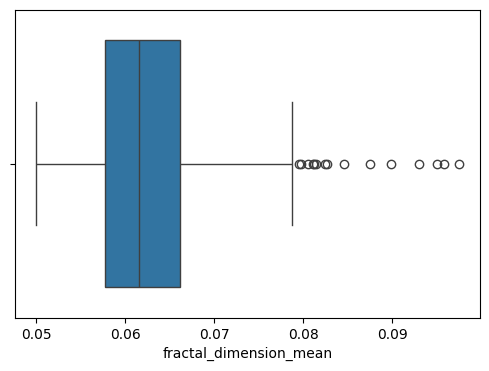

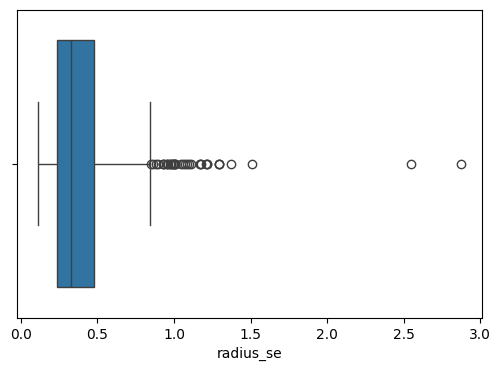

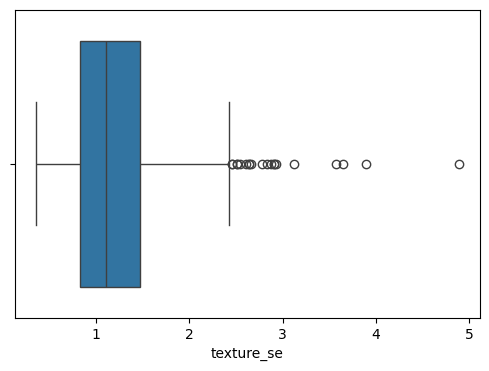

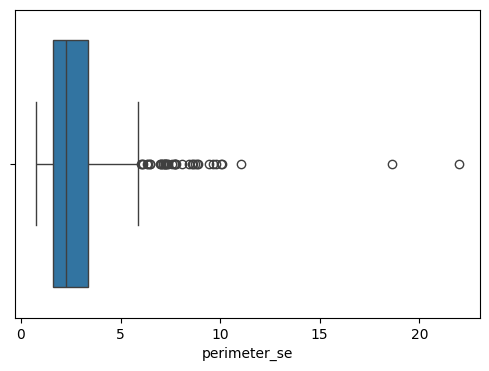

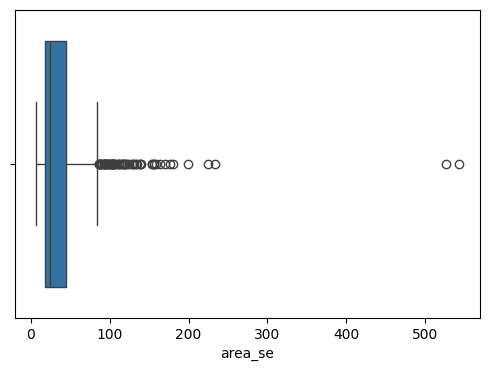

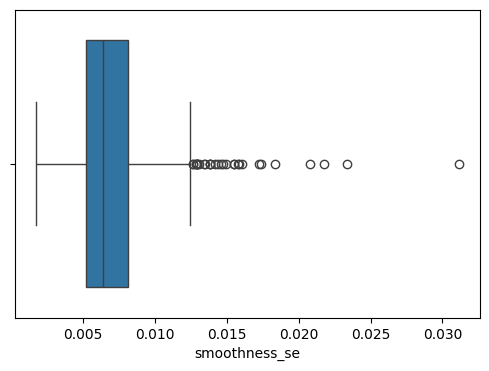

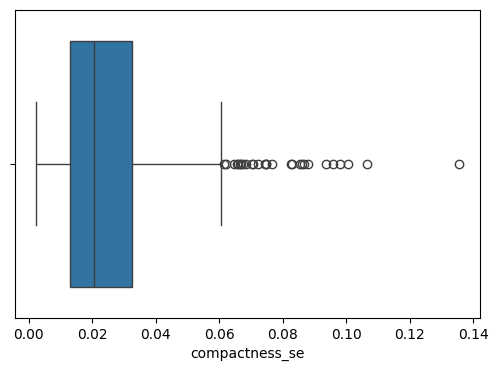

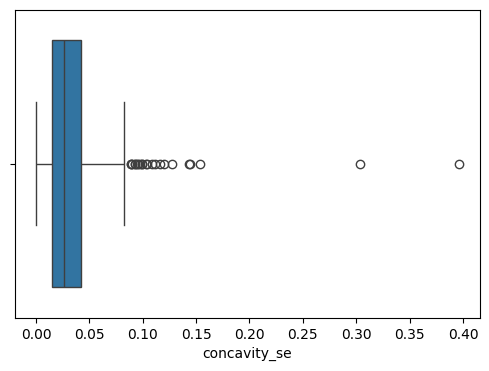

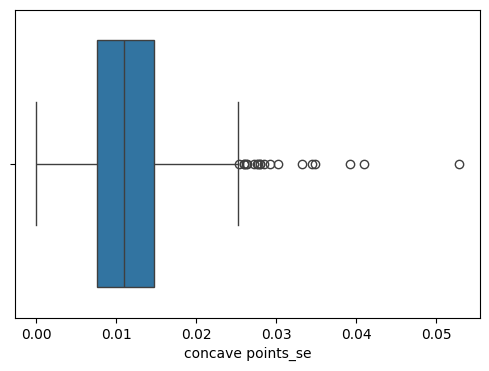

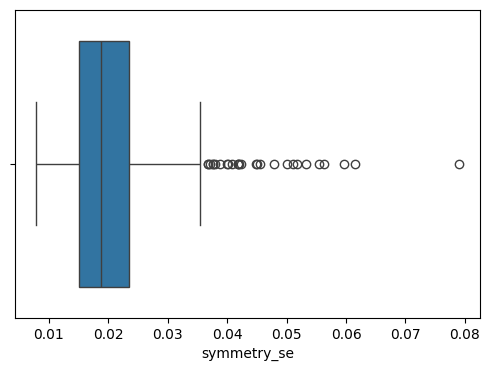

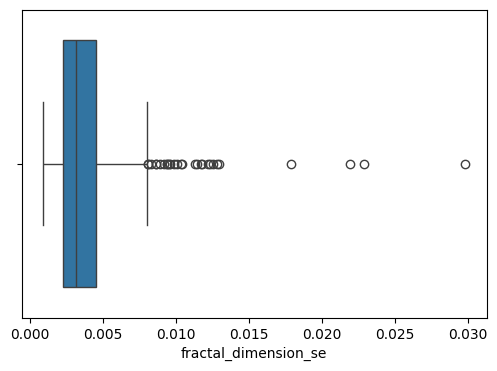

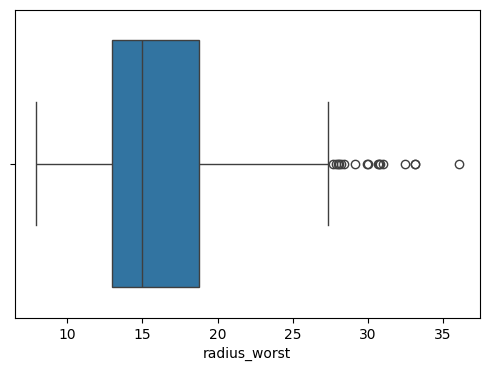

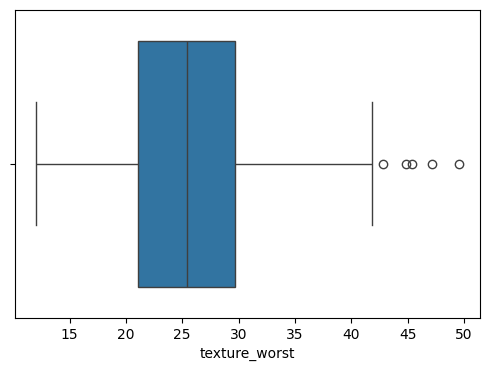

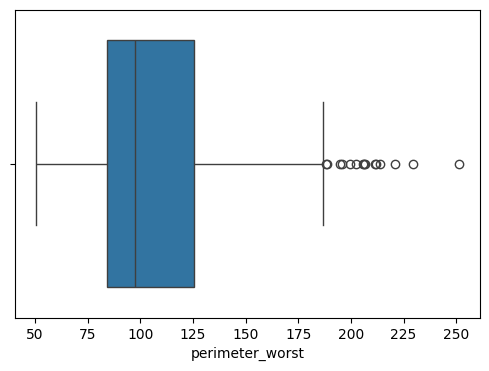

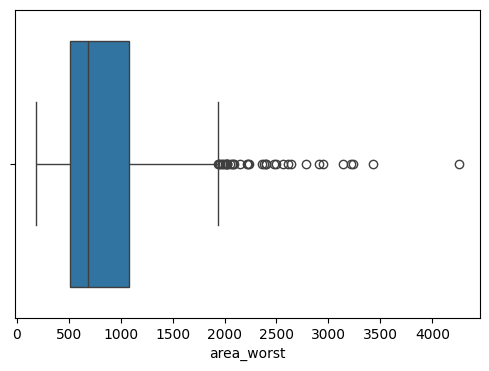

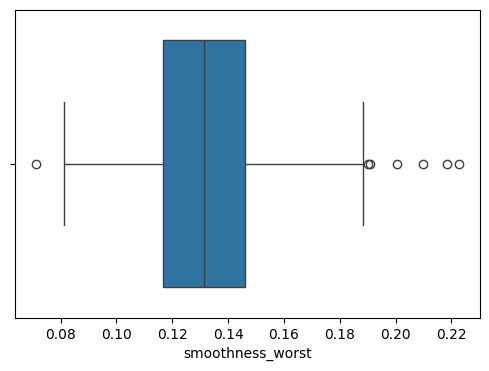

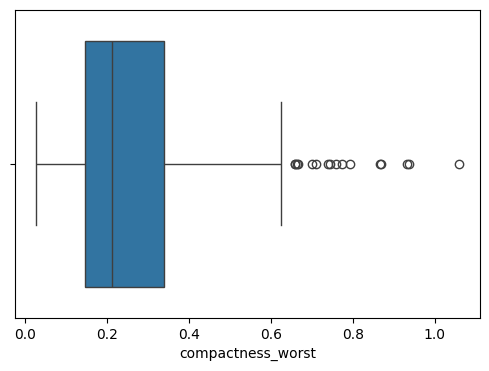

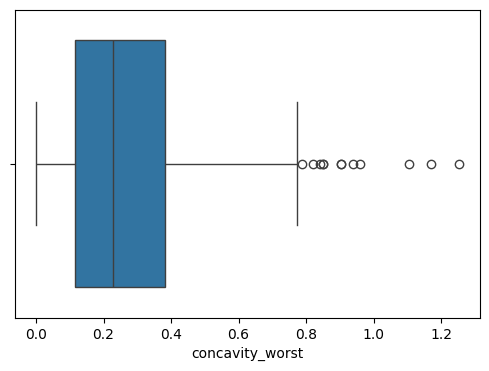

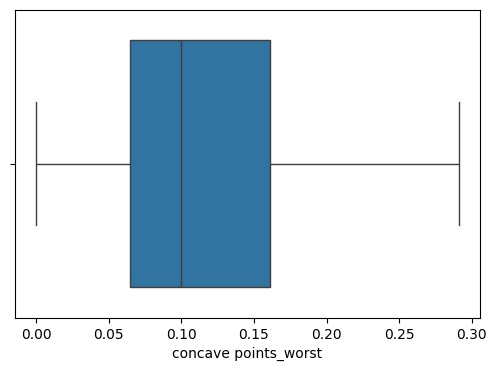

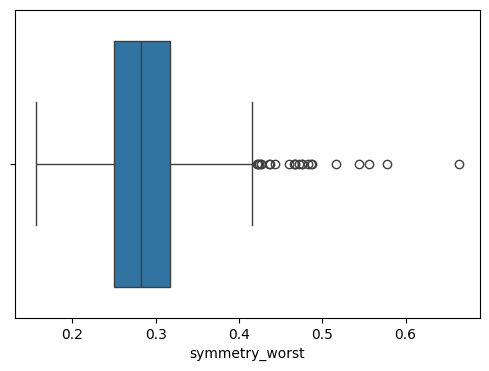

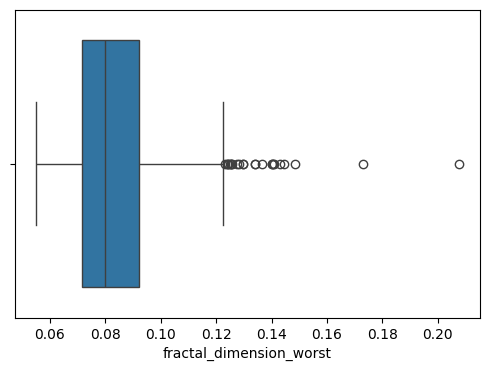

In [56]:
for col in numerical_col:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])
  plt.show()
  print("")

In [57]:
from sklearn.base import BaseEstimator, TransformerMixin

class MultiColIQRHandler(BaseEstimator, TransformerMixin):

    def __init__(self, columns, factor=1.5):
        self.columns = columns
        self.factor = factor

    def fit(self, X, y=None):
        # store values for each column
        self.stats_ = {}

        for col in self.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - self.factor * IQR
            upper_bound = Q3 + self.factor * IQR
            median_value = X[col].median()

            # store exactly what your function calculates
            self.stats_[col] = (lower_bound, upper_bound, median_value)

        return self

    def transform(self, X):
        X = X.copy()

        for col in self.columns:
            lower, upper, median = self.stats_[col]

            mask = (X[col] < lower) | (X[col] > upper)
            X.loc[mask, col] = median

        return X


In [58]:
numeric_pipeline = Pipeline(steps=[
    ("outliers", MultiColIQRHandler(columns=numerical_col)),
    ("scaler", StandardScaler())
])

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [60]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB(),
}



In [61]:
result = {}

for model_name, model in models.items():
    model = Pipeline([
      ('processing', numeric_pipeline),
      ('regressor', model)
  ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    score = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    result[model_name] = score
    print(f"{model_name}: {score}\n {cm}")
    print()



Logistic Regression: 0.9824561403508771
 [[72  0]
 [ 2 40]]

KNN: 0.9473684210526315
 [[72  0]
 [ 6 36]]

Decision Tree: 0.9473684210526315
 [[71  1]
 [ 5 37]]

Random Forest: 0.9649122807017544
 [[72  0]
 [ 4 38]]

Gradient Boosting: 0.9649122807017544
 [[72  0]
 [ 4 38]]

SVM: 0.9736842105263158
 [[72  0]
 [ 3 39]]

AdaBoost: 0.9736842105263158
 [[72  0]
 [ 3 39]]

Naive Bayes: 0.9473684210526315
 [[69  3]
 [ 3 39]]



In [62]:
results_df = pd.DataFrame.from_dict(result, orient='index', columns=['Accuracy']).sort_values(
    by="Accuracy", ascending=False
)

print("\n📊 FINAL MODEL COMPARISON")
print(results_df)


📊 FINAL MODEL COMPARISON
                     Accuracy
Logistic Regression  0.982456
SVM                  0.973684
AdaBoost             0.973684
Random Forest        0.964912
Gradient Boosting    0.964912
KNN                  0.947368
Decision Tree        0.947368
Naive Bayes          0.947368


In [63]:
from sklearn.model_selection import cross_val_score

# Find the model name with the maximum accuracy
best_model_name = max(result, key=result.get)

model = Pipeline([
      ('processing', numeric_pipeline),
      ('regressor', models[best_model_name])
  ])


cv_Accuracy = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
).mean()

print(f'📊 The best model is {best_model_name} with CROSS-VALIDATION:')
print(f"Accuracy: {cv_Accuracy:.4f}")


📊 The best model is Logistic Regression with CROSS-VALIDATION:
Accuracy: 0.9648
